In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    log_loss,
    brier_score_loss,
)

import seaborn as sns

# Load the dataset
df = pd.read_csv("../data/atp_matches_2000_2019_clean.csv")

# Features
X = [
    "rank_diff",
    "rank_points_diff",
    "age_diff",
    "elo_diff",
    "selo_diff",
    "comp_diff",
    "serv_diff",
    "form_diff",
]

# Target
y = "result"

# Empty storage lists
dates = []
predictions = []
actuals = []
probabilities = []
best_params_list = []
cv_monitor = []

# Rolling setup
WINDOW_SIZE = 10000   #4 years of data
STEP = 100

LOGIT = LogisticRegression(
    max_iter=5000,
    random_state=1
)

pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", LOGIT),
])

# Hyperparameter C grid
param_grid = {
    "clf__C": [0.01, 0.1, 1, 10]
}

# Rolling window forecast loop
for i in range(WINDOW_SIZE, len(df), STEP):
    train_data = df.iloc[i-WINDOW_SIZE:i]
    test_data = df.iloc[i:i+STEP]

    if len(test_data) == 0:
        break

    X_train = train_data[X]
    y_train = train_data[y]
    X_test = test_data[X]
    y_test = test_data[y]

    tscv = TimeSeriesSplit(n_splits=2)

    search = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=tscv,
        n_jobs=-1,
        scoring="neg_log_loss",
        refit=True,
        return_train_score=True
    )

    search.fit(X_train, y_train)

    # CV monitoring
    res = pd.DataFrame(search.cv_results_)
    best_row = res.iloc[search.best_index_]

    cv_monitor.append({
        "Index": i,
        "Date": test_data["tourney_date"].iloc[0],
        "Best_Params": search.best_params_,
        "Mean_Train_Score": float(best_row["mean_train_score"]),
        "Mean_Valid_Score": float(best_row["mean_test_score"]),
    })

    # Store predictions
    best_params_list.append(search.best_params_)
    dates.extend(test_data["tourney_date"].tolist())

    preds = search.predict(X_test)
    probs = search.predict_proba(X_test)[:, 1]

    predictions.extend(preds)
    probabilities.extend(probs)
    actuals.extend(y_test.tolist())

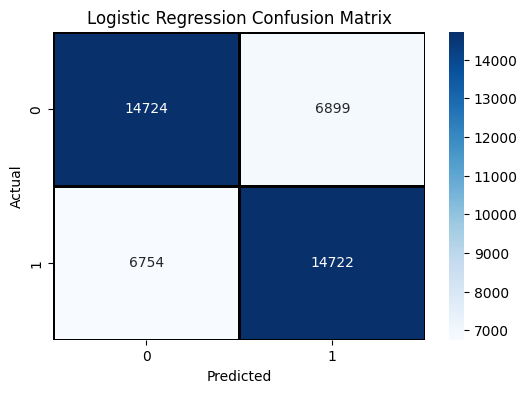

Balanced Accuracy: 0.683
Log Loss: 0.588
Brier Score: 0.202


In [23]:
#Confusion matrix
cm = confusion_matrix(actuals, predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", linewidths=1, linecolor='black')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

#Accuracy
accuracy = balanced_accuracy_score(actuals, predictions)
print(f"Balanced Accuracy: {accuracy:.3f}")

#Log loss
logloss = log_loss(actuals, probabilities)
print(f"Log Loss: {logloss:.3f}")

#Brier score
brier_score = brier_score_loss(actuals, probabilities)
print(f"Brier Score: {brier_score:.3f}")


            Feature  Coefficient  Abs_Coefficient
4         selo_diff     0.488576         0.488576
3          elo_diff     0.423907         0.423907
5         comp_diff     0.303471         0.303471
7         form_diff    -0.237905         0.237905
0         rank_diff    -0.178296         0.178296
2          age_diff    -0.153391         0.153391
1  rank_points_diff     0.080829         0.080829
6         serv_diff     0.071243         0.071243
8       height_diff     0.065122         0.065122
9    different_hand    -0.001789         0.001789


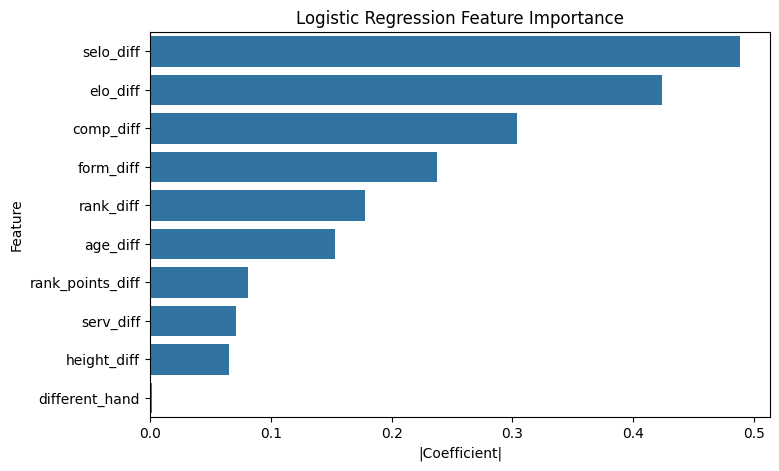

In [24]:
#RQ2: FEATURE IMPORTANCE

#Model fit and clf coefficients
pipe.fit(df[X], df[y])
coefficients = pipe.named_steps["clf"].coef_[0]

feature_importance_logit = pd.DataFrame({
    "Feature": X,
    "Coefficient": coefficients,
    "Abs_Coefficient": np.abs(coefficients)
}).sort_values(by="Abs_Coefficient", ascending=False)

print(feature_importance_logit)

#Visualization
plt.figure(figsize=(8,5))
sns.barplot(
    data=feature_importance_logit,
    x="Abs_Coefficient",
    y="Feature"
)
plt.title("Logistic Regression Feature Importance")
plt.xlabel("|Coefficient|")
plt.ylabel("Feature")
plt.show()



In [25]:
from collections import Counter
import pandas as pd

# Flatten all hyperparameters
all_params = {}
total = len(best_params_list)

for d in best_params_list:
    for key, value in d.items():
        if key not in all_params:
            all_params[key] = []
        all_params[key].append(value)

# Compute percentages
result = []
for param, values in all_params.items():
    counts = Counter(values)
    for val, count in counts.items():
        result.append({
            "Parameter": param,
            "Value": val,
            "Percentage": round(count / total * 100)
        })

# Convert to DataFrame
df_params = pd.DataFrame(result).sort_values(["Parameter", "Value"])

print(df_params)

  Parameter  Value  Percentage
0    clf__C   0.01          17
1    clf__C   0.10          64
3    clf__C   1.00           7
2    clf__C  10.00          12


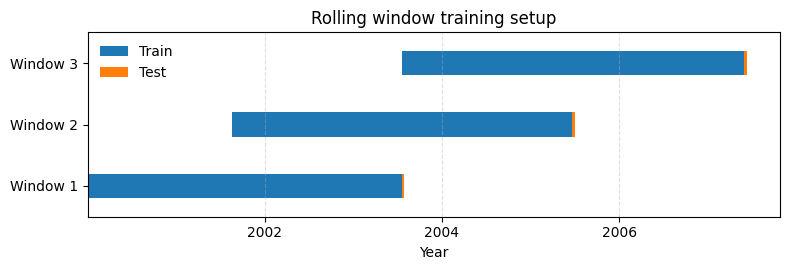

: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load data
df = pd.read_csv("../data/atp_matches_2000_2019_clean.csv")

# Convert and sort
df["tourney_date"] = pd.to_datetime(df["tourney_date"], errors="coerce")
df = df.sort_values("tourney_date").reset_index(drop=True)

# Parameters
WINDOW_SIZE = 10000
STEP = 100

# Example windows (early, middle, late)
example_indices = [
    WINDOW_SIZE,
    WINDOW_SIZE + 5000,
    WINDOW_SIZE + 10000
]

# Plot
fig, ax = plt.subplots(figsize=(8, 2.8))

for i, idx in enumerate(example_indices):
    train_start = df.iloc[idx - WINDOW_SIZE]["tourney_date"]
    train_end = df.iloc[idx - 1]["tourney_date"]
    test_start = df.iloc[idx]["tourney_date"]
    test_end = df.iloc[min(idx + STEP - 1, len(df)-1)]["tourney_date"]

    # TRAIN
    ax.barh(
        y=i,
        width=(train_end - train_start),
        left=train_start,
        height=0.4,
        color="tab:blue",
        label="Train" if i == 0 else ""
    )

    # TEST
    ax.barh(
        y=i,
        width=(test_end - test_start),
        left=test_start,
        height=0.4,
        color="tab:orange",
        label="Test" if i == 0 else ""
    )

# X-axis formatting
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Labels
ax.set_yticks(range(len(example_indices)))
ax.set_yticklabels(["Window 1", "Window 2", "Window 3"])

ax.set_xlabel("Year")
ax.set_title("Rolling window training setup")

# Light grid (keeps it clean)
ax.grid(axis="x", linestyle="--", alpha=0.4)

# Tight layout & spacing
ax.set_ylim(-0.5, len(example_indices) - 0.5)

# Legend
ax.legend(frameon=False)

plt.tight_layout()
plt.show()